In [1]:
# Reset e imports
%reset -f
import bagpy
from bagpy import bagreader
import pandas as pd
import seaborn as sea
import matplotlib.pyplot as plt
import numpy as np
import math
import gc
from sklearn.model_selection import TimeSeriesSplit
import re


In [2]:
b = bagreader(
    'MAC_aguas_claras_2025-01-21-12-07-24_0.bag'
    )

[INFO]  Data folder MAC_aguas_claras_2025-01-21-12-07-24_0 already exists. Not creating.


C:\Users\leoki\AppData\Local\Temp\ipykernel_16548\1040252213.py:108: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  telemetria.T_CPU=telemetria.T_CPU.fillna(method='ffill')
C:\Users\leoki\AppData\Local\Temp\ipykernel_16548\1040252213.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend(fontsize=18)


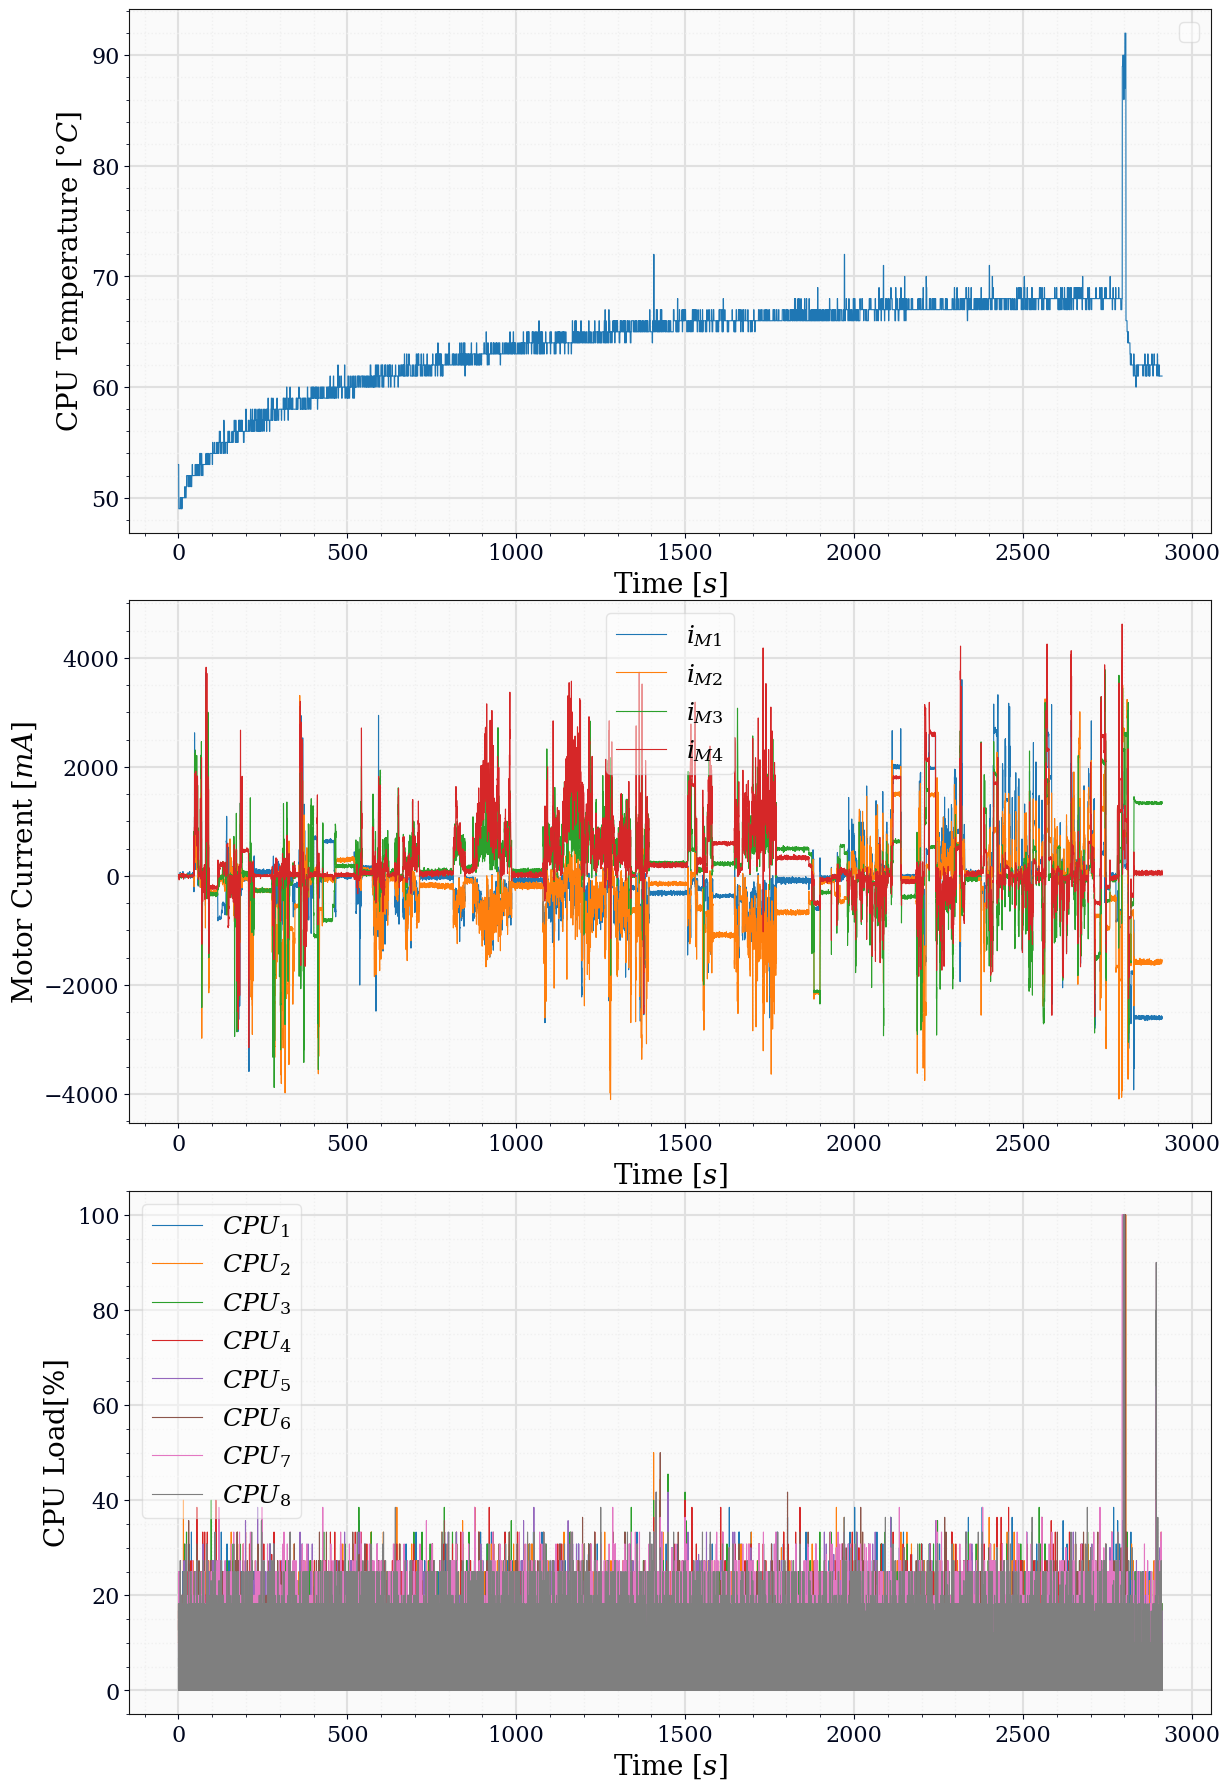

24905

In [3]:
# Cria a variável "telemetria" a partir da bag selecionada acima


# ===================== Desembaraça as mensagens salvas na bag =====================
# Temperatura da CPU
aux1 = b.message_by_topic('/cpu_temp')
aux1 = pd.read_csv(aux1)
aux1 = aux1.rename(columns={'data': 'T_CPU'})
aux1.Time = aux1.Time - b.start_time

# # Corrente instantânea da bateria 1
# aux2 = b.message_by_topic('/espeleo_io/battery_1_signed_status')
# aux2 = pd.read_csv(aux2)
# aux2 = aux2.drop(['layout.dim','layout.data_offset','data_0','data_2'],axis=1)
# aux2 = aux2.rename(columns={'data_1': 'i_B1'})
# aux2.i_B1=-aux2.i_B1
# aux2.Time = aux2.Time - b.start_time

# # Corrente média da bateria 1
# aux3 = b.message_by_topic('/espeleo_io/battery_1_signed_status')
# aux3 = pd.read_csv(aux3)
# aux3 = aux3.drop(['layout.dim','layout.data_offset','data_0','data_1'],axis=1)
# aux3 = aux3.rename(columns={'data_2': 'i_B1_avg'})
# aux3.i_B1_avg=-aux3.i_B1_avg
# aux3.Time = aux3.Time - b.start_time

# # Corrente instantânea da bateria 2
# aux4 = b.message_by_topic('/espeleo_io/battery_2_signed_status')
# aux4 = pd.read_csv(aux4)
# aux4 = aux4.drop(['layout.dim','layout.data_offset','data_0','data_2'],axis=1)
# aux4 = aux4.rename(columns={'data_1': 'i_B2'})
# aux4.i_B2=-aux4.i_B2
# aux4.Time = aux4.Time - b.start_time

# # Corrente média da bateria 2
# aux5 = b.message_by_topic('/espeleo_io/battery_2_signed_status')
# aux5 = pd.read_csv(aux5)
# aux5 = aux5.drop(['layout.dim','layout.data_offset','data_0','data_1'],axis=1)
# aux5 = aux5.rename(columns={'data_2': 'i_B2_avg'})
# aux5.i_B2_avg=-aux5.i_B2_avg
# aux5.Time = aux5.Time - b.start_time

# Corrente no motor 1
aux6 = b.message_by_topic('/device1/get_current_actual_value')
aux6 = pd.read_csv(aux6)
aux6 = aux6.rename(columns={'data': 'i_M1'})
aux6.Time = aux6.Time - b.start_time

# Corrente no motor 2
aux7 = b.message_by_topic('/device3/get_current_actual_value')
aux7 = pd.read_csv(aux7)
aux7 = aux7.rename(columns={'data': 'i_M2'})
aux7.Time = aux7.Time - b.start_time

# Corrente no motor 3
aux8 = b.message_by_topic('/device4/get_current_actual_value')
aux8 = pd.read_csv(aux8)
aux8 = aux8.rename(columns={'data': 'i_M3'})
aux8.Time = aux8.Time - b.start_time

# Corrente no motor 4
aux9 = b.message_by_topic('/device6/get_current_actual_value')
aux9 = pd.read_csv(aux9)
aux9 = aux9.rename(columns={'data': 'i_M4'})
aux9.Time = aux9.Time - b.start_time

# # Intensidade dos LEDs frontais
# aux10 = b.message_by_topic('/espeleo_io/frontLight')
# aux10 = pd.read_csv(aux10)
# aux10 = aux10.drop(['chooseLight'],axis=1)
# aux10 = aux10.rename(columns={'intensityLight': 'LED_F'})
# aux10.Time = aux10.Time - b.start_time

# # Intensidade dos LEDs traseiros
# aux11 = b.message_by_topic('/espeleo_io/backLight')
# aux11 = pd.read_csv(aux11)
# aux11 = aux11.drop(['chooseLight'],axis=1)
# aux11 = aux11.rename(columns={'intensityLight': 'LED_B'})
# aux11.Time = aux11.Time - b.start_time

# Porcentagem de utilizacao da CPU
aux12=b.message_by_topic('/cpu_percent')
aux12=pd.read_csv(aux12)
aux12.rename(columns=lambda col: re.sub(r'^data_(\d+)$', r'CPU_\1', col), inplace=True)
aux12.drop(['layout.dim','layout.data_offset'],axis=1,inplace=True)
aux12.Time = aux12.Time - b.start_time

# Resolve o número de CPUs
NumCPUs=len(aux12.columns)-1    # Se for rodado depois de retirar colunas de layout

# Monta um DataFrame consolidando todas as variáveis
# telemetria=pd.merge_ordered(aux1,aux2,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux3,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux4,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux5,on='Time',how='outer')
telemetria=pd.merge_ordered(aux1,aux6,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux7,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux8,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux9,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux10,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux11,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux12,on='Time',how='outer')
telemetria=telemetria.set_index('Time')
    

# ========================================== Limpa o DataFrame ==========================================
# Preenche os valores NaN com interpolação linear ou ZOH conforme o que faz mais sentido para cada variável.
telemetria.T_CPU=telemetria.T_CPU.fillna(method='ffill')
# telemetria.i_B1=telemetria.i_B1.interpolate(method='linear')
# telemetria.i_B1_avg=telemetria.i_B1_avg.interpolate(method='linear')
# telemetria.i_B2=telemetria.i_B2.interpolate(method='linear')
# telemetria=telemetria.rename(columns={'i_B2_x': 'i_B2'})
# telemetria.i_B2_avg=telemetria.i_B2_avg.interpolate(method='linear')
telemetria.i_M1=telemetria.i_M1.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M1_x': 'i_M1'})
telemetria.i_M2=telemetria.i_M2.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M2_x': 'i_M2'})
telemetria.i_M3=telemetria.i_M3.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M3_x': 'i_M3'})
telemetria.i_M4=telemetria.i_M4.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M4_x': 'i_M4'})
# telemetria.LED_F=telemetria.LED_F.fillna(method='ffill').fillna(0)
# telemetria.LED_F=telemetria.LED_F
# telemetria.LED_B=telemetria.LED_B.fillna(method='ffill').fillna(0)
# telemetria.LED_B=telemetria.LED_B.fillna(0)
for cpu in range(NumCPUs):     telemetria[f'CPU_{cpu}']=telemetria[f'CPU_{cpu}'].interpolate(method='linear')
telemetria=telemetria.dropna()

# Salva em arquivo do excel
telemetria.to_excel('telemetria.xlsx')
# Limpa variáveis desnecessárias
# del aux1, aux2, aux3, aux4, aux5, aux6, aux7, aux8, aux9, aux10, aux11, aux12
del aux1, aux6, aux7, aux8, aux9, aux12
gc.collect()

# ===================== Plota a telemetria extraída da bag e a média móvel da temperatura da CPU =====================
fig, ax = bagpy.create_fig(3)

ax[0].plot('T_CPU',     data = telemetria,      label = '',       linewidth=0.8)
ax[0].set_ylabel('CPU Temperature '+r'$[°C]$')
# ax[1].plot('i_B1',      data = telemetria,      label = r'$i_{B1}$',                linewidth=0.8)
# ax[1].plot('i_B2',      data = telemetria,      label = r'$i_{B2}$',                linewidth=0.8)
# ax[1].plot('i_B1_avg',  data = telemetria,      label = r'$\overline{i}_{B1}$',     linewidth=2)
# ax[1].plot('i_B2_avg',  data = telemetria,      label = r'$\overline{i}_{B2}$',     linewidth=2)
# ax[1].set_ylabel('Corrente da bateria '+r'$[mA]$')
ax[1].plot('i_M1',      data = telemetria,      label = r'$i_{M1}$',                linewidth=0.8)
ax[1].plot('i_M2',      data = telemetria,      label = r'$i_{M2}$',                linewidth=0.8)
ax[1].plot('i_M3',      data = telemetria,      label = r'$i_{M3}$',                linewidth=0.8)
ax[1].plot('i_M4',      data = telemetria,      label = r'$i_{M4}$',                linewidth=0.8)
ax[1].set_ylabel('Motor Current '+r'$[mA]$')
# ax[3].plot('LED_F',     data = telemetria,      label = r'$LED_{F}$',               linewidth=2, alpha=0.7)
# ax[3].plot('LED_B',     data = telemetria,      label = r'$LED_{B}$',               linewidth=2, alpha=0.7)
# ax[3].set_ylabel('Carga '+r'$[\%]$')
for cpu in range(NumCPUs):
    ax[2].plot(f'CPU_{cpu}',      data = telemetria,      label = fr'$CPU_{{{cpu+1}}}$',                linewidth=0.8)
ax[2].set_ylabel('CPU Load'+r'$[\%]$')

for axis in ax:
    axis.legend(fontsize=18)
    axis.set_xlabel('Time '+r'$[s]$')
    axis.set_facecolor('#fafafa')
    axis.grid(which='major', color='#e0e0e0', linewidth=1.5)
    axis.grid(which='minor', color='#f0f0f0', linewidth=1)

plt.savefig("Telemetry.svg", format='svg')
plt.show()

del ax, axis, fig
gc.collect()

In [27]:
#   Parâmetros para configuração do processamento de dados 
Window_temp=10          # Tamanho da janela usada para calcular a média móvel da T_CPU
Window_mot=10           # Tamanho da janela usada para calcular a média móvel das correntes dos motores
NumBuckets=10           # Em quantos buckets dividir a grandeza "dissipação"

#   Parâmetros para treinamento do modelo
target=['T_CPU']
features=[
            #'T_CPU',
            #'i_B1','i_B1_avg','i_B2','i_B2_avg',
            #'i_M1','i_M2','i_M3','i_M4',
            'T_CPU_trend',# 'T_CPU_detrend',
            'CPU_0','CPU_1','CPU_2','CPU_3','CPU_4','CPU_5','CPU_6','CPU_7',
            # 'LED_F', 'LED_B',
            # 'Dissip_B1','Dissip_B2',
            'Dissip_M1','Dissip_M2','Dissip_M3','Dissip_M4',
            'Dissip_CPU',
            #'T_CPU_lag'
          ]


# Parâmetros para validação cruzada
NumFolds=5
TamTeste=20000
GapTeste=500

In [ ]:
# Processamento de dados


# ======= Cria ou sobreescreve df para receber os cálculos =======
df=telemetria[target]
for f in features:
    if f in telemetria.columns: 
        df=df.merge(telemetria[f],left_index=True,right_index=True)
        


# ===================== Calcula a média móvel da temperatura da CPU =====================
trend=df[target].rolling(Window_temp).sum()/Window_temp                                 # Calcula a média móvel
df=df.merge(trend.rename(columns={'T_CPU':'T_CPU_trend'}),left_index=True, right_index=True)      # Acrescenta ao DataFrame


# Gera o feature "Dissipação" (quadrado da corrente, dividido em buckets conforme o valor)
# para cada corrente medida
# Calcula a "dissipação" devido às correntes
# diss_B1 = (telemetria['i_B1']/1000)**2 
# diss_B2 = (telemetria['i_B2']/1000)**2 
diss_M1 = (telemetria['i_M1']/1000)**2 
diss_M2 = (telemetria['i_M2']/1000)**2
diss_M3 = (telemetria['i_M3']/1000)**2
diss_M4 = (telemetria['i_M4']/1000)**2

# Calcula a média móvel para as dissipações nos motores
diss_M1=diss_M1.rolling(Window_mot).sum()/Window_mot
diss_M2=diss_M2.rolling(Window_mot).sum()/Window_mot
diss_M3=diss_M3.rolling(Window_mot).sum()/Window_mot
diss_M4=diss_M4.rolling(Window_mot).sum()/Window_mot


# Configura os buckets
# amplitude=max(max(diss_B1),max(diss_B2),max(diss_M1),max(diss_M2),max(diss_M3),max(diss_M4))
amplitude=max(max(diss_M1.dropna()),max(diss_M2.dropna()),max(diss_M3.dropna()),max(diss_M4.dropna()))

oom=10**math.floor(math.log10(amplitude))
BucketMax=math.ceil(amplitude/oom)*oom
BucketStep=BucketMax/NumBuckets


# Calcula a dissipação da CPU
if 'Dissip_CPU' in features: 
    diss_CPU=pd.DataFrame(data=telemetria['CPU_0']**2, index=telemetria.index)
    for i in range(1,NumCPUs):
        for j in range(len(telemetria)):
            diss_CPU.iloc[j]+=telemetria[f'CPU_{i}'].iloc[j]**2
    diss_CPU=diss_CPU/NumCPUs
    df=df.merge(right=diss_CPU.rename(columns={'CPU_0':'Dissip_CPU'}), right_index=True, left_index=True)


# ================== Calcula feature para baterias e inclui no DataFrame telemetria ==================
# Bateria 1
# df=df.merge(left_index=True, right_index=True, 
#             right=pd.DataFrame(
#                 index=telemetria.index, 
#                 data=np.floor(
#                     diss_B1.values
#                     /BucketStep)*BucketStep, 
#                 columns=['Dissip_B1'])
#             )

# Bateria 2
# df=df.merge(left_index=True, right_index=True, 
#             right=pd.DataFrame(
#                 index=telemetria.index, 
#                 data=np.floor(
#                     diss_B2.values
#                     /BucketStep)*BucketStep, 
#                 columns=['Dissip_B2'])
#             )

# Motor 1
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M1.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M1'])
            )

# M2
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M2.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M2'])
            )

# M3
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M3.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M3'])
            )

# M4
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M4.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M4'])
            )


df=df.dropna()

if False:   # Plotar as variáveis dissipação individuais?   
    fig, ax = plt.subplots(figsize=(15,5))
    diss_B1.plot(ax=ax,lw=0.8)
    diss_B2.plot(ax=ax,lw=0.8)
    diss_M1.plot(ax=ax,lw=0.8)
    diss_M2.plot(ax=ax,lw=0.8)
    diss_M3.plot(ax=ax,lw=0.8)
    diss_M4.plot(ax=ax,lw=0.8)
    ax.set_facecolor('#fafafa')
    ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
    ax.grid(which='minor', color='#f0f0f0', linewidth=1)
    del fig, ax


# ================== Cria lag feature e inclui no df ==================
df['T_CPU_lag']=df['T_CPU_trend'].shift(math.floor(-Window_temp/2))


# =============== Cria a feature detrend e inclui no df ===============
df['T_CPU_detrend']=telemetria['T_CPU']-df['T_CPU_trend']


# Limpa variáveis auxiliares
# del diss_B1, diss_B2, diss_M1, diss_M2, diss_M3, diss_M4
del diss_M1, diss_M2, diss_M3, diss_M4
del amplitude, BucketMax, BucketStep, oom
gc.collect()

31

Score across folds 2.6459
Fold scores:[np.float64(3.1361700696858983), np.float64(2.5963853982764302), np.float64(2.0545699517453744), np.float64(1.9380122092209842), np.float64(3.504599818350133)]


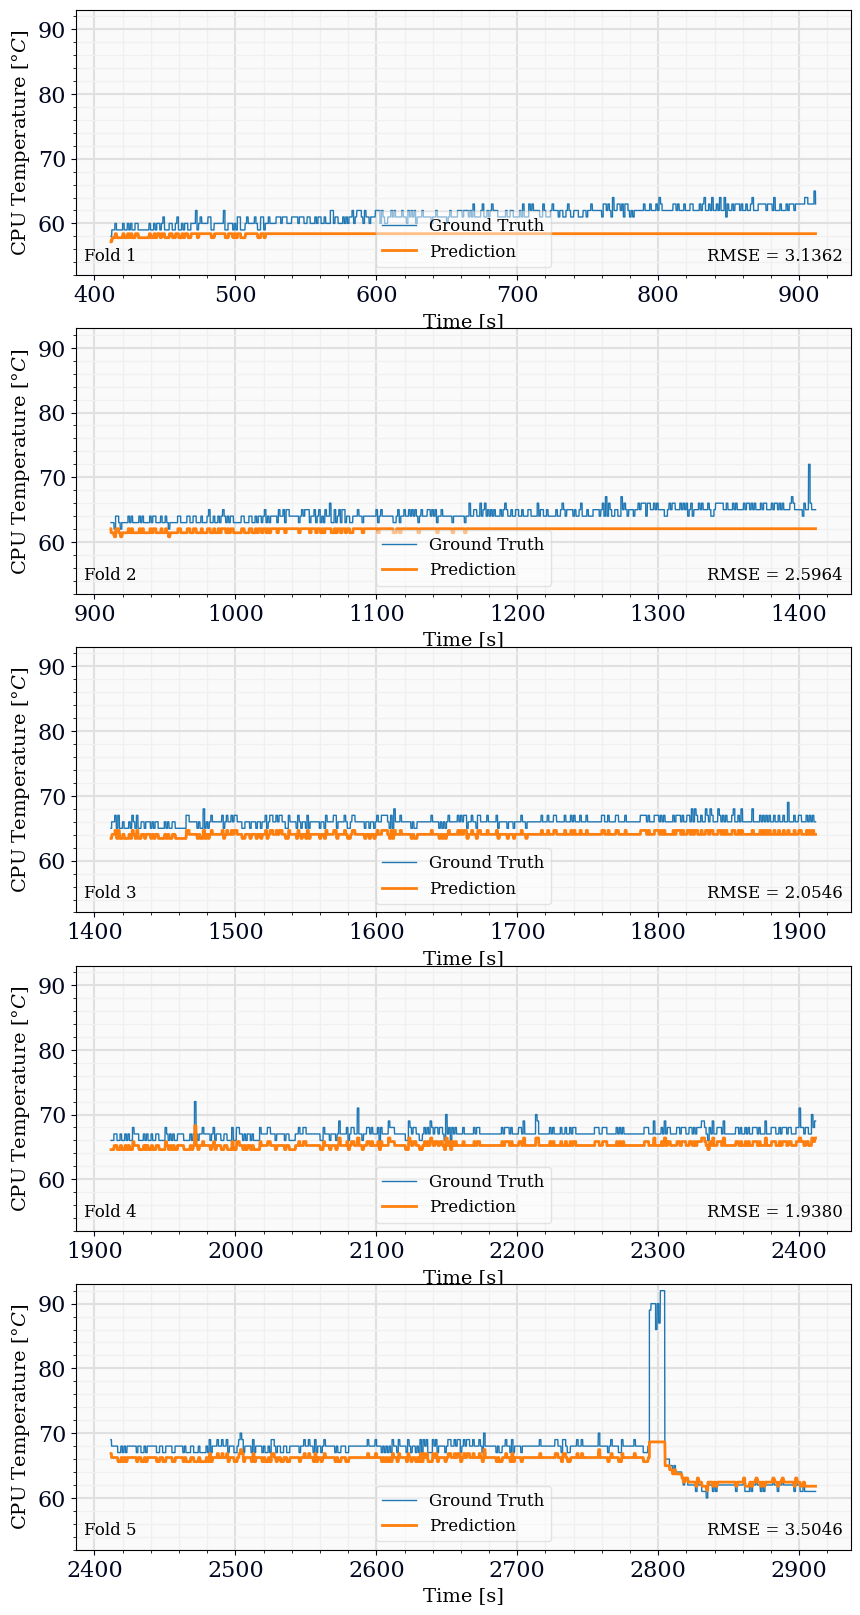

In [29]:
# Treina o modelo XGBoost e faz predições
import xgboost as xgb
from sklearn.metrics import mean_squared_error

tss = TimeSeriesSplit(n_splits=NumFolds, test_size=TamTeste, gap=GapTeste)
fig, ax = plt.subplots(nrows=NumFolds,ncols=1,figsize=(10,4*NumFolds))

fold=0
preds=[]
scores=[]
for train_idx, val_idx in tss.split(df):
        Train=df.iloc[train_idx]
        Test=df.iloc[val_idx]
        
        X_Train=Train[features]
        Y_Train=Train[target]
        X_Test=Test[features]
        Y_Test=Test[target]
        
        
        reg= xgb.XGBRegressor(n_estimators=1000,early_stopping_rounds=20, learning_rate=0.001)
        reg.fit(X_Train,Y_Train,
                eval_set=[(X_Train,Y_Train), (X_Test,Y_Test)],
                # verbose=300
                verbose=False
        )
        
        Y_Pred=reg.predict(X_Test)
        preds.append(Y_Pred)
        score=np.sqrt(mean_squared_error(Y_Test,Y_Pred))
        scores.append(score)
        ax[fold].plot('T_CPU', data=Y_Test, lw=1, label='Ground Truth')
        ax[fold].plot(Y_Test.index,Y_Pred, lw=2, label='Prediction')
        ax[fold].set_facecolor('#fafafa')
        ax[fold].grid(which='major', color='#e0e0e0', linewidth=1.5)
        ax[fold].grid(which='minor', color='#f0f0f0', linewidth=1)
        ax[fold].set_ylabel('CPU Temperature ['+r'$°C$'+']', fontsize=14)
        ax[fold].set_xlabel('Time [s]', fontsize=14)
        ax[fold].annotate(f'Fold {fold+1}', 
                xy=(0.01,0.04), xycoords='axes fraction', fontsize=12, horizontalalignment='left', verticalalignment='bottom')
        ax[fold].annotate(f'RMSE = {score:0.4f}',
                xy=(0.99,0.04), xycoords='axes fraction', fontsize=12, horizontalalignment='right', verticalalignment='bottom')
        ax[fold].legend(loc='lower center', fontsize=12)
        
        fold+=1
        
Y_max=max(max(telemetria['T_CPU']),max(np.concatenate(preds).ravel()))
Y_min=min(min(telemetria['T_CPU']),min(np.concatenate(preds).ravel()))
oom=10**(math.floor(math.log10(Y_max))-1)
for a in ax:
        a.set_ylim([math.floor(Y_min/oom)*oom+3,math.ceil(Y_max/oom)*oom+1])
        
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

plt.gcf().savefig("Predictions.svg",bbox_inches='tight')

C:\Users\leoki\AppData\Local\Temp\ipykernel_21784\67297499.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''])


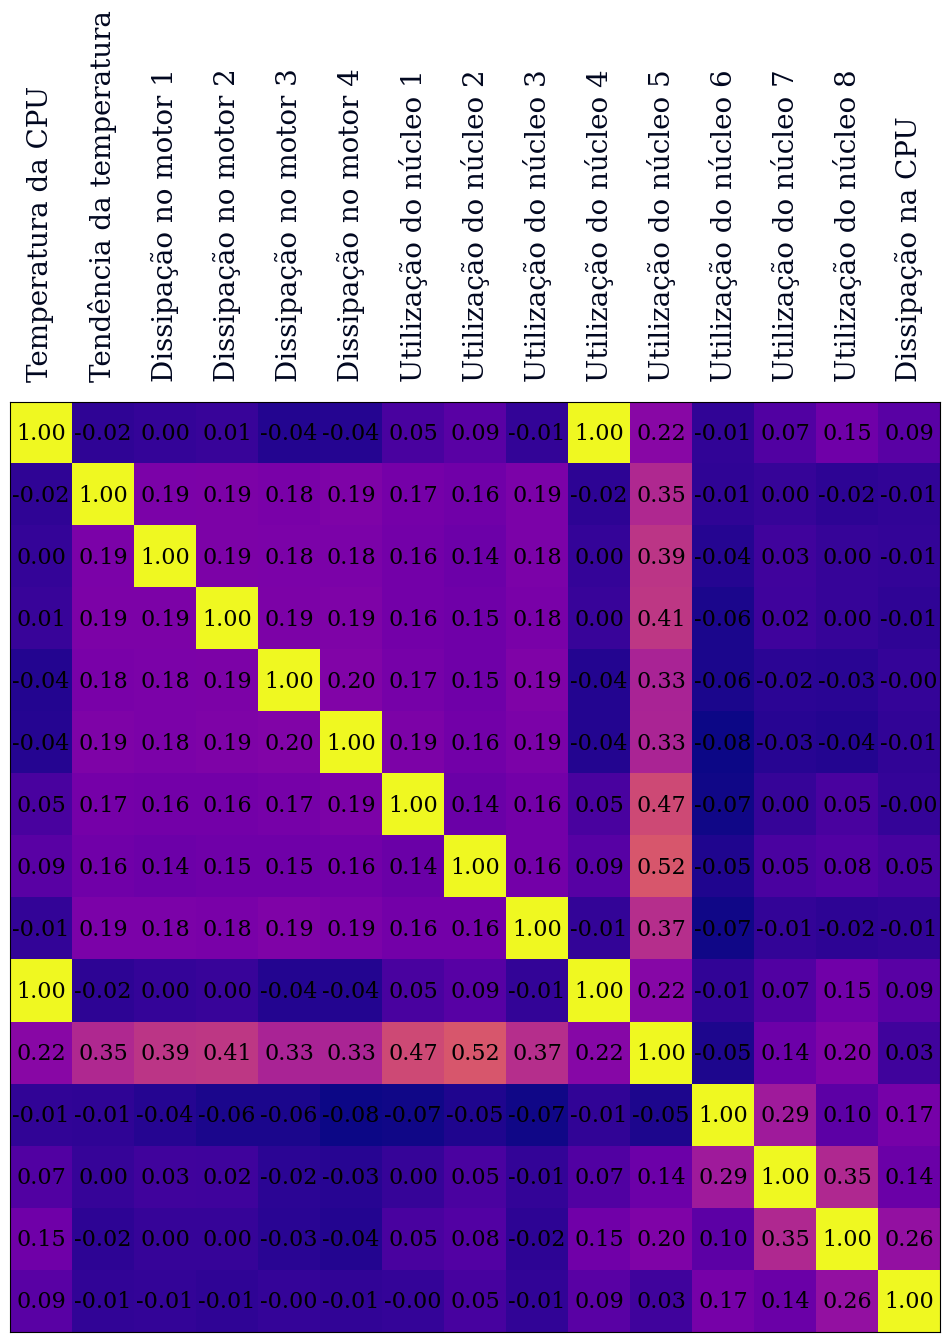

In [30]:
# Plota a matriz de covariância
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pylab

labels=[
    'Temperatura da CPU',
    # 'Carga no LED frontal',
    # 'Carga no LED traseiro',
    'Tendência da temperatura',
    # 'Dissipação na bateria 1',
    # 'Dissipação na bateria 2',
    'Dissipação no motor 1',
    'Dissipação no motor 2',
    'Dissipação no motor 3',
    'Dissipação no motor 4',
    'Utilização do núcleo 1',
    'Utilização do núcleo 2',
    'Utilização do núcleo 3',
    'Utilização do núcleo 4',
    'Utilização do núcleo 5',
    'Utilização do núcleo 6',
    'Utilização do núcleo 7',
    'Utilização do núcleo 8',
    'Dissipação na CPU',
]
mat=df.drop(columns={'T_CPU_lag','T_CPU_detrend'}).corr()

pylab.rcParams['xtick.major.pad']='15'
ax=plt.figure().add_subplot(111)
im=ax.matshow(mat,cmap=plt.colormaps['plasma'])
N=len(mat.columns)
for i in range(N):
    for j in range(N):
        t=str("{n:.2f}".format(n=mat.iloc[[i],[j]].values[0][0]))
        ax.text(i, j, t, va='center', ha='center',fontsize=16)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels,rotation='vertical',fontsize=20)
ax.set_yticklabels([''])
ax.tick_params(axis=u'both', which=u'both',length=0)
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="5%", pad=0.5)   
# plt.colorbar(im, cax=cax)
plt.gcf().savefig("CovMatrix.svg",bbox_inches='tight')


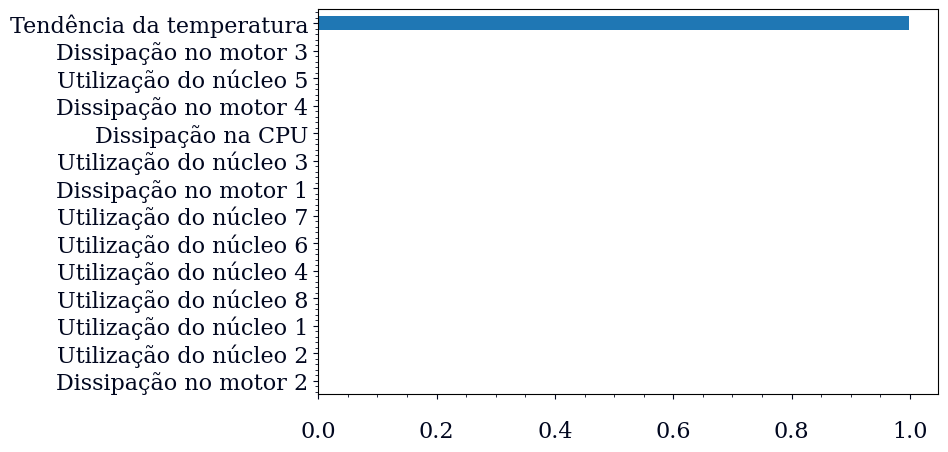

In [32]:
# Plota as importâncias relativas de cada feature
dict={
    'T_CPU_trend':'Tendência da temperatura',
    'LED_F':'Carga no LED frontal',
    'LED_B':'Carga no LED traseiro',
    'Dissip_B1':'Dissipação na batteria 1',
    'Dissip_B2':'Dissipação na batteria 2',
    'Dissip_M1':'Dissipação no motor 1',
    'Dissip_M2':'Dissipação no motor 2',
    'Dissip_M3':'Dissipação no motor 3',
    'Dissip_M4':'Dissipação no motor 4',
    'Dissip_CPU':'Dissipação na CPU',
    'CPU_0':'Utilização do núcleo 1',
    'CPU_1':'Utilização do núcleo 2',
    'CPU_2':'Utilização do núcleo 3',
    'CPU_3':'Utilização do núcleo 4',
    'CPU_4':'Utilização do núcleo 5',
    'CPU_5':'Utilização do núcleo 6',
    'CPU_6':'Utilização do núcleo 7',
    'CPU_7':'Utilização do núcleo 8'
}
fi=pd.DataFrame(index=reg.feature_names_in_, data=reg.feature_importances_, columns=['importance'])
fi=fi.sort_values('importance')
fi=fi.rename(index=dict)
fi.plot(kind='barh',figsize=(8,5))
plt.gca().get_legend().remove()
plt.gcf().savefig("ImportancePlot.svg",bbox_inches='tight')

/tmp/ipykernel_1504/1724886174.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[0].add_patch(ptc.Rectangle(xy=[t,ymin],width=-MovingAverageWindow,height=5,


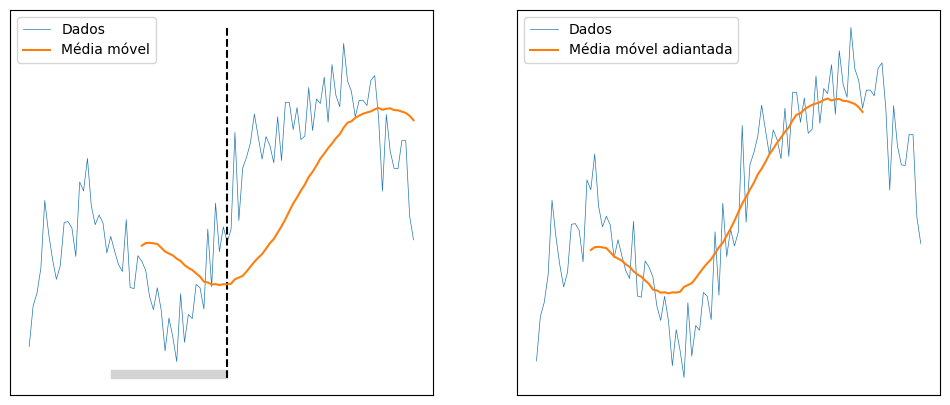

In [8]:
# Plota um gráfico ilustrativo do procedimento de cálculo do feature T_CPU_trend
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ptc
import random
import math
Layer1Size=10
EscalaX=10
EscalaY=10
PreSmoothWindow=20
MovingAverageWindow=30

# Layer 1: Define a um vetor base manualmente. Dita a forma aproximada
x1=np.array(range(Layer1Size+2))*EscalaX
y1=np.array([0,0.08618527251172858,0.29276664037142175,0.17339907077578998,0.3148968679197107,0.2636046903087258,0.3962135971001429,0.4595127291716007,0.759708333177639,0.4605307631477288,0.5453521650684118,0.5453521650684118])
y1=y1+np.random.normal(scale=0.3,size=y1.shape)
y1=y1*EscalaY
x=np.array(range(max(x1)+1))
y=np.interp(x,x1,y1)
y=np.convolve(y, np.ones(PreSmoothWindow), mode='same')

# Layer 2: Acrescenta ruído de alta frequência
x=x[0:Layer1Size*EscalaX]
y=y[0:Layer1Size*EscalaX]
y=y+np.random.normal(scale=20,size=y.shape)

# Raw data
t=math.floor(0.75*(max(x)-MovingAverageWindow))
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(x,y,lw=0.5,label='Dados')
ymin, ymax = np.array(ax[0].get_ylim())
ax[0].add_patch(ptc.Rectangle(xy=[t,ymin],width=-MovingAverageWindow,height=5,
                           color='lightgray',edgecolor='black',lw=1))
ax[0].plot([t,t],[ymin, ymax],ls='--',color='black')

# Moving average
MA=np.convolve(y, np.ones(MovingAverageWindow)/MovingAverageWindow, mode='valid')
ax[0].plot(x[MovingAverageWindow-1:x.size],MA,label='Média móvel')
ax[0].legend()
ax[0].set_xticks([])
ax[0].set_yticks([])

offset=math.floor(MovingAverageWindow/2)
ax[1].plot(x,y,lw=0.5,label='Dados')
ax[1].plot(x[MovingAverageWindow-1-offset:x.size-offset],MA,label='Média móvel adiantada')
ax[1].legend()
ax[1].set_xticks([])
ax[1].set_yticks([])

fig.savefig("MovingAverage.svg",bbox_inches='tight')


C:\Users\leoki\AppData\Local\Temp\ipykernel_21784\2532223018.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend(fontsize=18)


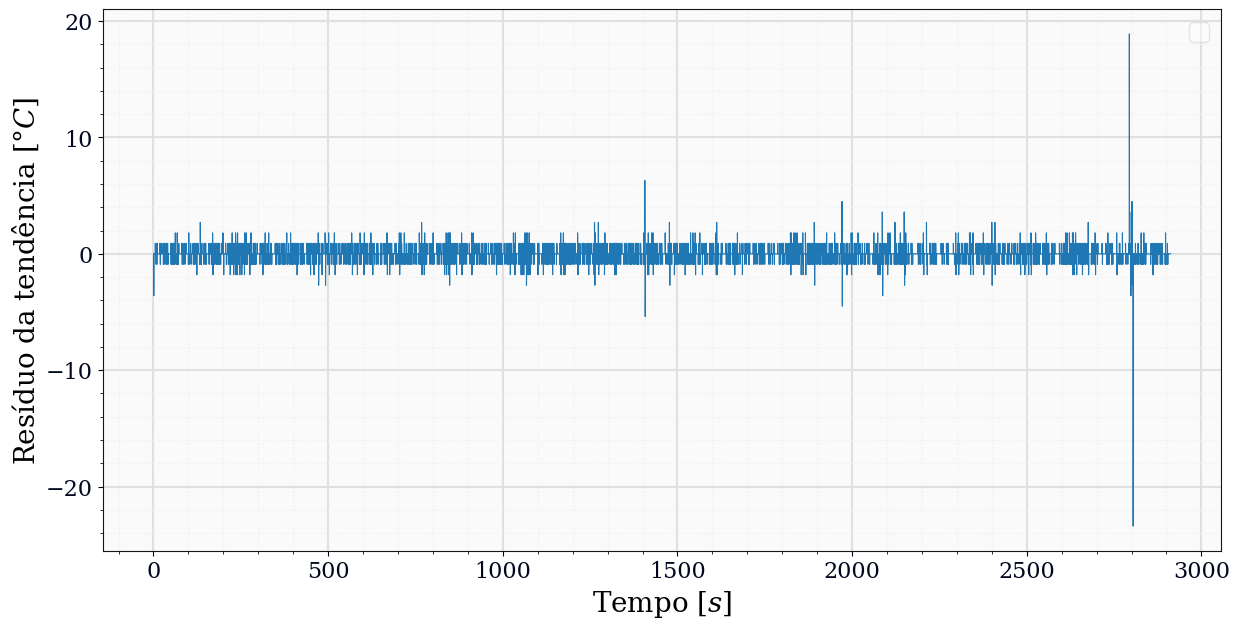

In [15]:
# Plota um gráfico da série temperatura x tempo do resíduo do detrend de T_CPU
fig, ax = bagpy.create_fig(1)
ax[0].plot('T_CPU_detrend',     data = df,      label='',       linewidth=0.8)
ax[0].set_ylabel('Resíduo da tendência '+r'$[°C]$')
for axis in ax:
    axis.legend(fontsize=18)
    axis.set_xlabel('Tempo '+r'$[s]$')
    axis.set_facecolor('#fafafa')
    axis.grid(which='major', color='#e0e0e0', linewidth=1.5)
    axis.grid(which='minor', color='#f0f0f0', linewidth=1)

plt.savefig("TempDetrend.svg",bbox_inches='tight')
plt.show()


In [ ]:
diss_CPU=pd.DataFrame(data=telemetria['CPU_0']**2, index=telemetria.index)
for i in range(1,NumCPUs):
    for j in range(len(telemetria)):
        diss_CPU.iloc[j]+=telemetria[f'CPU_{i}'].iloc[j]**2
diss_CPU=diss_CPU/NumCPUs